In [404]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib inline

Analyze the assignment

In [405]:
# Test case
res = 48
procs = 144
case = f"c{res}_p{procs}"

reassign_types = [
    "greedy",
    "nearest_greedy",
    "bilinear_greedy",
    "bicubic_greedy",
]
reassgins = {}

In [406]:
# Load the CSV files
og_assign = pd.read_csv(f"test/og_assignments/{case}.csv", index_col=0)
for sim_type in reassign_types:
    file_path = f"test/{sim_type}/{case}/assignment.csv"
    reassgins[sim_type] = pd.read_csv(file_path, index_col=0)

# Trim the original dataframe to match the upscaled intervals
upscaled_df = reassgins["bilinear_greedy"]
original_df = reassgins["greedy"]
original_df = original_df[upscaled_df.columns]

# Rename the columns to match the upscaled intervals
nintervals = len(upscaled_df.columns)
intervals = range(nintervals)
upscaled_df.columns = intervals
original_df.columns = intervals

In [407]:
# Track the target processor the original and reassignment decide to assign for each processor at each interval
# Also track how many times it is assigned to that processor
# Assuming there is up to one target processor per processor at each interval
def count_assignments(
    assign: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Count the number of assignments for each processor at each interval.
    """
    samples, intervals = assign.shape
    counts = np.zeros((procs, intervals), dtype=int)
    targets = -np.ones((procs, intervals), dtype=int)

    # Expand original assignments to match shape of assign
    og_expanded = np.tile(og_assign.values, (1, intervals))

    # Mask where assignments differ
    mask = assign.values != og_expanded

    # Get processor indices and interval indices where reassignment occurred
    reassigned_proc = assign.values[mask]
    original_proc = og_expanded[mask]
    interval_idx = np.tile(np.arange(intervals), samples)[mask.ravel()]

    # Count assignments and set targets
    for proc, orig, idx in zip(reassigned_proc, original_proc, interval_idx):
        counts[proc, idx] += 1
        targets[proc, idx] = orig

    return pd.DataFrame(
        counts, index=range(procs), columns=assign.columns
    ), pd.DataFrame(targets, index=range(procs), columns=assign.columns)

In [408]:
# Count it for greedy heuristic on both the original and upscaled workloads
og_counts, og_targets = count_assignments(original_df, og_assign, procs)

# Print the first interval of the counts and targets
print("Original workload counts:", og_counts.iloc[:, 0].values)
print("Original workload targets:", og_targets.iloc[:, 0].values)

Original workload counts: [10 21 18  2 17 29 17 20 17 15 26  3 14 21  2 14 14 19 25 12 25 26  3 10
 25 11  5 26 20 24 17 19  5 18 25 21  1  2 33 23 14 19 25 25  1 26 22 20
  1 26 14 17  4 18  9 12 10  5  8  1  1  8 15  1 11  9  3 23 20 18  1  7
 17 19 15 15  4  3 10  5  4 25  3  9 22 23  9  8 19 14  2  4 19  9  9 14
 20 16 17  8 18  3  3 21 12 18 20 32 24 29 30  7 35 20  1  4  7  4 14  5
 16 13 19 25 24 17 19 23 19 13 33 12  3 30 35  5  7 32 26 19 20 24 19 19]
Original workload targets: [ 78 103 105  90 125 109  30 106  51  75  49 132  40  35  37 118  95  31
 123  55  42  45  66  56  34  64 119 138  68 108   6  17  57  53  24  13
  70  14 130  67  12 139  20  81  60  21  84 140  59  10  89   8 115  33
  86  19  23  32  87  48  44  99  74 114  25  93  22  39  28 100  36 116
  98 142  62   9  80 102   0 135  76  43 101  94  46 127  54  58 128  50
   3 117 126  65  83  16 113 120  72  61  69  82  77   1 131   2   7 137
  29   5 133 136 134  96  63  52  71  91  15  26  97 129 143  18 141  

In [409]:
upscaled_counts, upscaled_targets = count_assignments(upscaled_df, og_assign, procs)

print("Upscaled workload counts:", upscaled_counts.iloc[:, 0].values)
print("Upscaled workload targets:", upscaled_targets.iloc[:, 0].values)

Upscaled workload counts: [ 7 16 18  7 22 22 23 19 13  9 20  7 15 21  4 16 12 27 22  7 22 27  8 16
 26  7  7 27 21 26 18 20  4 15 27 22  2  2 33 25 18 19 26 27  3 28 23 22
  1 28 15 18  8 21 10 10 14  5 11  1  4 10 17 10 13  9  8 18 22 15  2 21
 18 22 17 17  3  3 12  8  5 30  1  7 27 28 16  4 26 25  6  4 19 18 14 14
 24 20 22  6 19  8  4 19 12 16 19 34 26 30 30  9 35 22  4  3  9  1 14  8
 16 11 21 26 23 19 21 24 20  7 35  9  2 34 33  4 12 30 28 23  9 19 18 17]
Upscaled workload targets: [ 11  15  72  19  47 113  46 125  64 116 128   0  50 122  91   1 104  43
  35   3  68  27 101 120  42  26  25  21  53 108  67  97  60  69  84  18
 132  70 134  89  93  92  24  17  77  85   6   4  82 138  12 142  66  28
  61  63 118  80 121 117  32  54  75  55   8 131  52  30  20  33  37 126
   2  98 143  62 115  44 136 119  57 109  48 129  34  45 105 102 123  39
  99  14  41  40  95  94 127  31  73  90 103  22  87 100  16  86 141 133
  29  81 137 140 130   5 135  76   9  59  56  79  23  58  13  88 139  

In [410]:
# Tally for each interval, how many times does the upscaled workload assigns to a different processor than the original workload
target_diff = upscaled_targets != og_targets
target_diff_count = target_diff.sum(axis=0)

print("Target difference counts:", target_diff_count.values)


Target difference counts: [142 118 132 128 118 120 128 128 132 122 110 122 120 124 120 124 130 112
 132 126 128 120 116 134 118 124 124 122 124 124 126 120 124 122 118 122
 128 132 126 132 120 120 126 130 126 122 116 120 134 126 116 134 128 126
 130 134 128 132 126 124 130 132 118 126 116 122 122 128 132 126 134 126]


Compare the workload
Hypothesis: the highest workload and lowest workload processors are predicted correctly.

In [ ]:
# Read the workload data
workload_df = pd.read_csv(f"test/workloads/c{res}.csv", index_col=0, header=0)

nearest_workload_df = pd.read_csv(f"temp/workloads/nearest_c24_to_c{res}.csv", index_col=0, header=0)
bilinear_workload_df = pd.read_csv(f"temp/workloads/bilinear_c24_to_c{res}.csv", index_col=0, header=0)
bicubic_workload_df = pd.read_csv(f"temp/workloads/bicubic_c24_to_c{res}.csv", index_col=0, header=0)

# Trim the original workload to match the upscaled intervals
workload_df = workload_df[bilinear_workload_df.columns]

In [412]:
# Compute the workload for each processor at each interval using the original assignments
def compute_workload(
    workload_df: pd.DataFrame, og_assign: pd.DataFrame, procs: int
) -> pd.DataFrame:
    """
    Compute the workload for each processor at each interval.
    """
    _, intervals = workload_df.shape
    workload = np.zeros((procs, intervals), dtype=float)
    assigned_procs = og_assign.values.flatten()

    for interval in range(intervals):
        np.add.at(
            workload[:, interval], assigned_procs, workload_df.values[:, interval]
        )

    return pd.DataFrame(workload, index=range(procs), columns=workload_df.columns)

In [413]:
# Compute the workload for the original workload df
og_workload = compute_workload(workload_df, og_assign, procs)

og_max_indices = og_workload.idxmax(axis=0)
rows = og_max_indices.values
cols = np.arange(len(og_workload.columns))
og_max_values = og_workload.values[rows, cols]

In [414]:
# Compute the workload for the bilinear workload df
bilinear_workload = compute_workload(bilinear_workload_df, og_assign, procs)

bilinear_max_indices = bilinear_workload.idxmax(axis=0)
rows = bilinear_max_indices.values
cols = np.arange(len(bilinear_workload.columns))
bilinear_max_values = bilinear_workload.values[rows, cols]

In [415]:
# Check how many times the upscaled workload predicts the max workload processor correctly
correct_predictions = bilinear_max_indices == og_max_indices
correct_predictions_count = correct_predictions.sum()
print("Correct predictions count:", correct_predictions_count)

# For each of those correct predictions, check how far off the predicted workload is from the actual workload
ratios = bilinear_max_values[correct_predictions] / og_max_values[correct_predictions]

# Compute summary statistics for the ratios
median_ratio = np.nanmedian(ratios)
geo_mean_ratio = np.exp(np.nanmean(np.log(ratios[ratios > 0])))
within_1_percent = np.mean((ratios >= 0.99) & (ratios <= 1.01)) * 100
mape = np.mean(np.abs(1 - ratios)) * 100

# Repeat the computation but including all predictions
ratios_all = bilinear_max_values / og_max_values

# Compute summary statistics for the ratios
median_ratio_all = np.nanmedian(ratios_all)
geo_mean_ratio_all = np.exp(np.nanmean(np.log(ratios_all[ratios_all > 0])))
within_1_percent_all = np.mean((ratios_all >= 0.99) & (ratios_all <= 1.01)) * 100
mape_all = np.mean(np.abs(1 - ratios_all)) * 100

# Create summary table
summary_table = pd.DataFrame(
    {
        "Median Ratio": [median_ratio, median_ratio_all],
        "Geometric Mean Ratio": [geo_mean_ratio, geo_mean_ratio_all],
        "% Within 1%": [within_1_percent, within_1_percent_all],
        "MAPE (%)": [mape, mape_all],
    },
    index=["Correct", "All"],
)

print(summary_table)

Correct predictions count: 64
         Median Ratio  Geometric Mean Ratio  % Within 1%  MAPE (%)
Correct      0.998255              0.998463    78.125000  0.656646
All          0.998418              0.998481    77.777778  0.644333


In [416]:
# Absolute difference
abs_diff_correct = np.abs(
    bilinear_max_values[correct_predictions] - og_max_values[correct_predictions]
)
abs_diff_all = np.abs(bilinear_max_values - og_max_values)


abs_diff_table = pd.DataFrame(
    {
        "mean": [np.mean(abs_diff_correct), np.mean(abs_diff_all)],
        "std": [np.std(abs_diff_correct), np.std(abs_diff_all)],
        "min": [np.min(abs_diff_correct), np.min(abs_diff_all)],
        "max": [np.max(abs_diff_correct), np.max(abs_diff_all)],
        "median": [np.median(abs_diff_correct), np.median(abs_diff_all)],
    },
    index=["Correct", "All"],
)
print(abs_diff_table)

               mean         std      min        max   median
Correct  385.451172  281.249253  14.9375  1200.3125  311.125
All      376.381944  275.151528  14.9375  1200.3125  311.125


In [417]:
# Absolute ratio deviation
ratios_correct = (
    bilinear_max_values[correct_predictions] / og_max_values[correct_predictions]
)
ratios_all = bilinear_max_values / og_max_values
abs_ratio_dev_correct = np.abs(ratios_correct - 1)
abs_ratio_dev_all = np.abs(ratios_all - 1)

abs_ratio_table = pd.DataFrame(
    {
        "mean": [
            abs_ratio_dev_correct.mean(),
            abs_ratio_dev_all.mean(),
        ],
        "std": [
            np.std(abs_ratio_dev_correct),
            np.std(abs_ratio_dev_all),
        ],
        "min": [
            np.min(abs_ratio_dev_correct),
            np.min(abs_ratio_dev_all),
        ],
        "median": [
            np.median(abs_ratio_dev_correct),
            np.median(abs_ratio_dev_all),
        ],
        "max": [
            np.max(abs_ratio_dev_correct),
            np.max(abs_ratio_dev_all),
        ],
    },
    index=["Correct", "All"],
)
print(abs_ratio_table)

             mean       std       min   median       max
Correct  0.006566  0.004779  0.000259  0.00555  0.020952
All      0.006443  0.004690  0.000259  0.00555  0.020952


In [418]:
# Now rather than just comparing the max workload per processor, compare the entire workload
# Compute the absolute difference between the bilinear and original workloads, and summarize the results
abs_diff_workload = np.abs(bilinear_workload.values - og_workload.values)
abs_diff_workload_df = pd.DataFrame(
    abs_diff_workload, index=range(procs), columns=workload_df.columns
)
abs_diff_workload_summary = abs_diff_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_diff_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_diff_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_diff_workload_summary)

                      mean         std      min     median        max
20190701_0000z  925.271701  594.296318   9.5625  841.71875  2571.5000
20190701_0020z  963.206597  565.757386  59.3125  913.81250  3216.5000
20190701_0040z  590.335069  487.785505   3.6250  494.90625  2456.3125
20190701_0100z  575.543403  413.471159   2.6250  469.40625  2018.9375
20190701_0120z  621.907986  446.071099  16.2500  588.43750  2620.1875
...                    ...         ...      ...        ...        ...
20190701_2220z  653.154514  548.012393   3.0000  536.59375  3396.9375
20190701_2240z  645.847222  541.102036   1.1250  486.75000  3414.5000
20190701_2300z  665.555556  566.272526   8.3750  525.68750  3341.6875
20190701_2320z  642.620660  545.498625   4.0000  502.90625  3467.2500
20190701_2340z  646.668403  585.402530   7.3125  494.78125  3526.2500

[72 rows x 5 columns]


In [419]:
# Repeat the same for the ratios
ratios_workload = bilinear_workload.values / og_workload.values
ratios_workload_df = pd.DataFrame(
    ratios_workload, index=range(procs), columns=workload_df.columns
)
ratios_workload_summary = ratios_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
ratios_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
ratios_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(ratios_workload_summary)

                    mean       std       min    median       max
20190701_0000z  1.016325  0.056320  0.828166  1.026100  1.150976
20190701_0020z  1.059135  0.047845  0.983195  1.053316  1.226975
20190701_0040z  1.033771  0.039965  0.965614  1.023510  1.215112
20190701_0100z  1.033572  0.033819  0.961911  1.027149  1.143496
20190701_0120z  1.037721  0.035440  0.962286  1.031687  1.152425
...                  ...       ...       ...       ...       ...
20190701_2220z  1.036851  0.038869  0.958830  1.025887  1.217504
20190701_2240z  1.035990  0.039202  0.968803  1.027213  1.238063
20190701_2300z  1.037386  0.040614  0.959736  1.031078  1.229811
20190701_2320z  1.034342  0.039004  0.962650  1.026138  1.201367
20190701_2340z  1.034598  0.041901  0.957722  1.025615  1.234022

[72 rows x 5 columns]


In [420]:
# And absolute ratio deviation
abs_ratio_dev_workload = np.abs(ratios_workload - 1)
abs_ratio_dev_workload_df = pd.DataFrame(
    abs_ratio_dev_workload, index=range(procs), columns=workload_df.columns
)
abs_ratio_dev_workload_summary = abs_ratio_dev_workload_df.describe().T
# Drop the count, 25%, and 75% columns, and rename the 50% column to median
abs_ratio_dev_workload_summary.drop(columns=["count", "25%", "75%"], inplace=True)
abs_ratio_dev_workload_summary.rename(
    columns={
        "50%": "median",
    },
    inplace=True,
)
print(abs_ratio_dev_workload_summary)

                    mean       std       min    median       max
20190701_0000z  0.046206  0.035921  0.000408  0.039461  0.171834
20190701_0020z  0.060360  0.046280  0.001237  0.053316  0.226975
20190701_0040z  0.037528  0.036434  0.000348  0.025907  0.215112
20190701_0100z  0.036516  0.030593  0.000080  0.028079  0.143496
20190701_0120z  0.040048  0.032769  0.000373  0.032212  0.152425
...                  ...       ...       ...       ...       ...
20190701_2220z  0.039113  0.036577  0.000179  0.026596  0.217504
20190701_2240z  0.038724  0.036484  0.000058  0.027441  0.238063
20190701_2300z  0.040189  0.037822  0.000417  0.032188  0.229811
20190701_2320z  0.038315  0.035080  0.000313  0.029475  0.201367
20190701_2340z  0.038892  0.037919  0.000327  0.026564  0.234022

[72 rows x 5 columns]


In [421]:
from scipy.stats import spearmanr

methods = {
    "nearest": compute_workload(nearest_workload_df, og_assign, procs),
    "bilinear": compute_workload(bilinear_workload_df, og_assign, procs),
    "bicubic": compute_workload(bicubic_workload_df, og_assign, procs),
}

summary_table = {}

for name, pred_workload in methods.items():
    correlations = [
        spearmanr(og_workload.iloc[i].values, pred_workload.iloc[i].values)[0]
        for i in range(procs)
    ]
    stats = pd.Series(correlations).describe()
    summary_table[name] = {
        "mean": stats["mean"],
        "std": stats["std"],
        "min": stats["min"],
        "median": stats["50%"],
        "max": stats["max"],
    }

# Create and display the final summary table
correlation_summary_df = pd.DataFrame(summary_table).T[
    ["mean", "std", "min", "median", "max"]
]
print(correlation_summary_df)

              mean       std       min    median       max
nearest   0.982410  0.018077  0.902154  0.988548  0.997419
bilinear  0.982535  0.020911  0.864426  0.989485  0.998456
bicubic   0.982517  0.020286  0.851355  0.989035  0.998071


In [422]:
# Compute the spearman correlation for each interval
def compute_spearman_correlation(
    og_workload: pd.DataFrame, pred_workload: pd.DataFrame
) -> pd.Series:
    """
    Compute the spearman correlation for each interval.
    """
    correlations = [
        spearmanr(og_workload.iloc[:, i].values, pred_workload.iloc[:, i].values)[0]
        for i in range(og_workload.shape[1])
    ]
    return pd.Series(correlations)

# Compute the spearman correlation
nearest_correlation = compute_spearman_correlation(workload_df, nearest_workload_df)
bilinear_correlation = compute_spearman_correlation(workload_df, bilinear_workload_df)
bicubic_correlation = compute_spearman_correlation(workload_df, bicubic_workload_df)

# Summary statistics
nearest_correlation_summary = nearest_correlation.describe()
nearest_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
nearest_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bilinear_correlation_summary = bilinear_correlation.describe()
bilinear_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bilinear_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)
bicubic_correlation_summary = bicubic_correlation.describe()
bicubic_correlation_summary.drop(index=["count", "25%", "75%"], inplace=True)
bicubic_correlation_summary.rename(
    index={
        "50%": "median",
    },
    inplace=True,
)

# Combine all summaries into a single table
correlation_table = pd.DataFrame(
    {
        "nearest": nearest_correlation_summary,
        "bilinear": bilinear_correlation_summary,
        "bicubic": bicubic_correlation_summary,
    }
)

# Print the table with comma as separator
print(correlation_table.to_string(index=True, header=True, float_format="%.3f"))

        nearest  bilinear  bicubic
mean      0.938     0.950    0.949
std       0.011     0.010    0.011
min       0.895     0.913    0.910
median    0.943     0.955    0.955
max       0.950     0.961    0.961


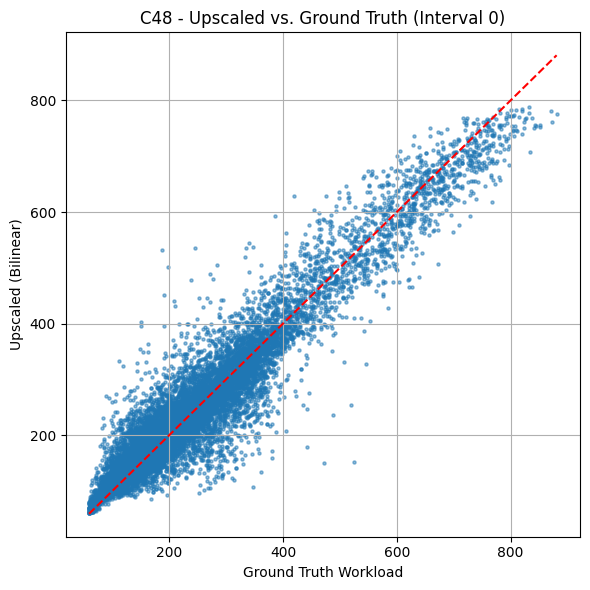

In [423]:
import matplotlib.pyplot as plt

interval = 0  # start with a representative interval
x = workload_df.iloc[:, interval].array
y = bilinear_workload_df.iloc[:, interval].array

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth (Interval {interval})")
plt.grid(True)
plt.tight_layout()
plt.show()

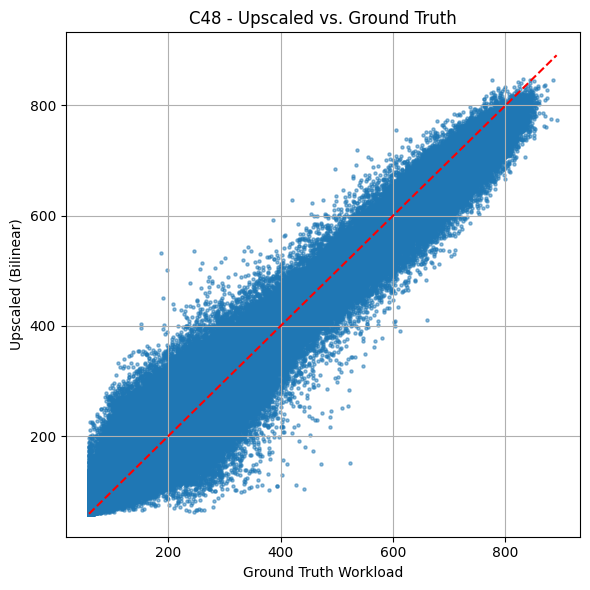

In [424]:
# Repeat it but using data from all intervals
x = workload_df.values.flatten()
y = bilinear_workload_df.values.flatten()
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5, s=5)
plt.plot([x.min(), x.max()], [x.min(), x.max()], color="red", linestyle="--")
plt.xlabel("Ground Truth Workload")
plt.ylabel("Upscaled (Bilinear)")
plt.title(f"C{res} - Upscaled vs. Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

Compare the simulated workspan

In [ ]:
# Read all the simulation data
simulation_types = ["original", "greedy", "nearest_greedy", "bilinear_greedy", "bicubic_greedy"]
simulations = {}

for sim_type in simulation_types:
    if sim_type == "original":
        file_path = f"test/og_assignments/{case}_simulation.csv"
    else:
        file_path = f"test/{sim_type}/{case}/simulation.csv"
    simulations[sim_type] = pd.read_csv(file_path)

In [ ]:
# Generate an animation showing the workload distribution for all the simulation types
fig, ax = plt.subplots(figsize=(160, 6))
bar_width = 0.15
bars = []

# Exclude 'Interval' column and the last 4 Max,Mean,SD,CV columns
ylim = max(simulations[simulation_types[i]].iloc[:, 1:-4].max().max() * 1.1 for i in range(len(simulation_types)))
xlabels = simulations[simulation_types[0]].columns[1:-4]
x = np.arange(len(xlabels))

def init():
    ax.clear()
    ax.margins(x=0)
    ax.set_ylim(0, ylim)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title("Workload Distribution per Processor")
    fig.tight_layout()
    return bars

def update(frame):
    ax.clear()
    ax.margins(x=0)
    for i, sim_type in enumerate(simulation_types):
        sim_data = simulations[sim_type]
        workloads = sim_data.iloc[frame, 1:-4]
        bar = ax.bar(x + i * bar_width, workloads, bar_width, label=sim_type)
        bars.append(bar)
    # Plot a dotted reference line for the mean workload
    mean = simulations[simulation_types[0]].iloc[frame, -3]
    ax.axhline(mean, color="red", linestyle="--", label="Mean Workload")

    ax.set_ylim(0, ylim)
    ax.set_xticks(x + bar_width * (len(simulation_types)-1)/2)
    ax.set_xticklabels(xlabels, rotation=90)
    ax.set_ylabel("Workload")
    ax.set_title(f"Workload Distribution per Processor (Interval {frame})")
    ax.legend(
        loc="upper right",
        title="Simulation Type",
        fontsize="small",
    )
    fig.tight_layout()
    return bars

ani = FuncAnimation(
    fig,
    update,
    frames=range(len(simulations[simulation_types[0]])),
    init_func=init,
    blit=False,
)

ani.save(f"{case}_anim.gif", writer="imagemagick")